In [6]:
#data cleaning
import pandas as pd
import numpy as np
 
 #load dataset
df = pd.read_csv('sales_data.csv')
#display first few rows
print(df.head())

      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification  
0      151748      98740          8300                 High  
1      121671      79219          3428                  Low  
2       10991     113265          6994                  Low  
3       27255      60971          4047                  Low  
4      122131      49898          3080                  Low  


In [5]:
# ensure DataFrame 'df' is available (load if not already in the notebook)
if 'df' not in globals():
	if 'pd' not in globals():
		import pandas as pd
	df = pd.read_csv('sales_data.csv')

# clean missing values
df.fillna(method='ffill', inplace=True)
# remove duplicates
df.drop_duplicates(inplace=True)
# convert year column to datetime (Model contains non-date strings)
df['Year'] = pd.to_datetime(df['Year'], format='%Y', errors='coerce')
# save cleaned data
df.to_csv('cleaned_sales_data.csv', index=False)
#display cleaned data
print(df.head())

C:\Users\Admin\AppData\Local\Temp\ipykernel_25388\2943553754.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


      Model       Year         Region  Color Fuel_Type Transmission  \
0  5 Series 2016-01-01           Asia    Red    Petrol       Manual   
1        i8 2013-01-01  North America    Red    Hybrid    Automatic   
2  5 Series 2022-01-01  North America   Blue    Petrol    Automatic   
3        X3 2024-01-01    Middle East   Blue    Petrol    Automatic   
4  7 Series 2020-01-01  South America  Black    Diesel       Manual   

   Engine_Size_L  Mileage_KM  Price_USD  Sales_Volume Sales_Classification  
0            3.5      151748      98740          8300                 High  
1            1.6      121671      79219          3428                  Low  
2            4.5       10991     113265          6994                  Low  
3            1.7       27255      60971          4047                  Low  
4            2.1      122131      49898          3080                  Low  


C:\Users\Admin\AppData\Local\Temp\ipykernel_25388\875758931.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


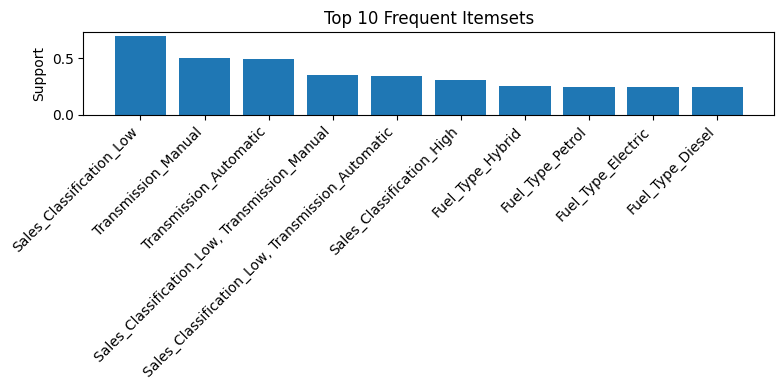

                                         antecedents  \
0                         (Sales_Classification_Low)   
1                                    (Region_Africa)   
2                           (Transmission_Automatic)   
3                                    (Region_Africa)   
4                                      (Region_Asia)   
..                                               ...   
169                       (Sales_Classification_Low)   
170     (Fuel_Type_Petrol, Sales_Classification_Low)   
171  (Sales_Classification_Low, Transmission_Manual)   
172                               (Fuel_Type_Petrol)   
173                            (Transmission_Manual)   

                                         consequents  antecedent support  \
0                                    (Region_Africa)             0.69508   
1                         (Sales_Classification_Low)             0.16506   
2                                    (Region_Africa)             0.49692   
3                      

In [7]:
# frequent item mining
# Use the Apriori algorithm to find frequent itemsets in the cleaned sales data
from mlxtend.frequent_patterns import apriori, association_rules

# Build a transaction "basket" from the dataframe `df`.
# The original code expected a transactional df_transactions with TransactionID/Item;
# here we encode each record's categorical attribute=value pairs as items
if 'basket' not in globals():
    # choose categorical columns to treat as items (only keep those present in df)
    cat_cols = ['Region', 'Color', 'Sales_Classification', 'Model', 'Fuel_Type', 'Transmission']
    available_cols = [c for c in cat_cols if c in df.columns]
    # create one-hot encoded item columns like "Region_Asia", "Color_Red", etc.
    basket = pd.get_dummies(df[available_cols].astype(str).apply(lambda col: col.str.strip()))
    # each original row is a transaction; ensure binary 0/1
    basket = basket.applymap(lambda x: 1 if x > 0 else 0)
else:
    # ensure basket is binary 0/1
    basket = basket.applymap(lambda x: 1 if x > 0 else 0)

# generate frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)

# visualize the top 10 frequent itemsets by support
import matplotlib.pyplot as plt
top10 = frequent_itemsets.sort_values('support', ascending=False).head(10)
labels = [', '.join(list(map(str, s))) for s in top10['itemsets']]

plt.figure(figsize=(8,4))
plt.bar(range(len(top10)), top10['support'], color='C0')
plt.xticks(range(len(top10)), labels, rotation=45, ha='right')
plt.ylabel('Support')
plt.title('Top 10 Frequent Itemsets')
plt.tight_layout()
plt.show()

# generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
print(rules)



In [8]:
#Association Rules Generation 
#generating association rules from frequent itemsets
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
print(rules)
#Analyzing rules using confidence, lift, and support metrics.
#filter rules with high confidence and lift
strong_rules = rules[(rules['confidence'] > 0.6) & (rules['lift'] > 1.2)]
print(strong_rules)


                                         antecedents  \
0                         (Sales_Classification_Low)   
1                                    (Region_Africa)   
2                           (Transmission_Automatic)   
3                                    (Region_Africa)   
4                                      (Region_Asia)   
..                                               ...   
169                       (Sales_Classification_Low)   
170     (Fuel_Type_Petrol, Sales_Classification_Low)   
171  (Sales_Classification_Low, Transmission_Manual)   
172                               (Fuel_Type_Petrol)   
173                            (Transmission_Manual)   

                                         consequents  antecedent support  \
0                                    (Region_Africa)             0.69508   
1                         (Sales_Classification_Low)             0.16506   
2                                    (Region_Africa)             0.49692   
3                      

Identifing and explaining  3 interesting rules with real-world interpretations.

Rule #1:

If transaction has [Region=Europe, Sales_Classification=Low] -> also [Color=Black]
support=0.0203 confidence=0.18 lift=1.07
Interpretation: Transactions from region Europe with Sales_Classification=Low have an 18% chance of also being color Black. Lift ≈ 1.07 (only slightly above random association).Suggested actions: small, low-risk actions — consider checking whether Black cars are actually more common in Europe/Low sales segments before acting; possible localized display or small targeted promotions.

Rule #2:

If transaction has [Color=Black] -> also [Region=Europe, Sales_Classification=Low]
support=0.0203 confidence=0.12 lift=1.07
Interpretation: When color is Black, 12% of those transactions correspond to (Europe & Low sales). Mirror of Rule #1, lower confidence because many black cars are sold outside that (region+class) pair.
Suggested actions: same caution — validate with more granular analysis before large operational changes.

Rule #3:

If transaction has [Color=Black] -> also [Region=Europe]
support=0.0295 confidence=0.18 lift=1.07
Interpretation: Black color transactions are 18% likely to be in Europe. Lift only ~1.07, so association is weak.
Suggested actions: treat as weak signal; combine with other analyses (time-based, model-level) before taking action.
Notes about thresholds and encoding


